In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

from linear_regression import LinearRegression
from logistic_regression import LogisticRegression

In [5]:
# Reload and re-run cleaning steps
df = pd.read_csv('../data/josaa_data.csv')

PAPER2_KEYWORDS = ['Architecture', 'Planning']
paper2_mask = df['Academic Program Name'].str.contains('|'.join(PAPER2_KEYWORDS), case=False, na=False)
print(f"Removed {paper2_mask.sum()} Paper-2 rows (Architecture/Planning).")
df = df[~paper2_mask].reset_index(drop=True)
# ── END ADD ──

df_final = df[df['Round'] == df.groupby('Year')['Round'].transform('max')]
df_clean = df_final.dropna(subset=['Closing Rank', 'Opening Rank', 'Gender', 'Seat Type', 'Quota']).copy()

df_clean['Seat_Key'] = (
    df_clean['Institute'] + ' | ' +
    df_clean['Academic Program Name'] + ' | ' +
    df_clean['Quota'] + ' | ' +
    df_clean['Seat Type'] + ' | ' +
    df_clean['Gender']
)

years_per_seat = df_clean.groupby('Seat_Key')['Year'].count()
valid_seats = years_per_seat[years_per_seat >= 3].index
df_model = df_clean[df_clean['Seat_Key'].isin(valid_seats)]

print("Ready. Shape:", df_model.shape)

Removed 13354 Paper-2 rows (Architecture/Planning).
Ready. Shape: (60292, 10)


In [6]:
# Test on IIT Bombay CSE OPEN Gender-Neutral
test_key = 'Indian Institute of Technology Bombay | Computer Science and Engineering (4 Years, Bachelor of Technology) | AI | OPEN | Gender-Neutral'

seat = df_model[df_model['Seat_Key'] == test_key].sort_values('Year')

X = seat['Year'].values.reshape(-1, 1)
y = seat['Closing Rank'].values

# Normalize year — important for numerical stability
X_norm = (X - X.mean()) / X.std()

# Train
model = LinearRegression()
model.fit(X_norm, y)

# Predict 2026
X_2026 = np.array([[(2026 - X.mean()) / X.std()]])
predicted = model.predict(X_2026)[0]

print(f"Historical closing ranks:\n{dict(zip(seat['Year'].values, y))}")
print(f"\nPredicted closing rank for 2026: {predicted:.0f}")
print(f"RMSE on training data: {model.rmse(X_norm, y):.2f}")

Historical closing ranks:
{np.int64(2018): np.float64(59.0), np.int64(2019): np.float64(63.0), np.int64(2020): np.float64(66.0), np.int64(2021): np.float64(67.0), np.int64(2022): np.float64(61.0), np.int64(2024): np.float64(68.0), np.int64(2025): np.float64(66.0)}

Predicted closing rank for 2026: 68
RMSE on training data: 2.46


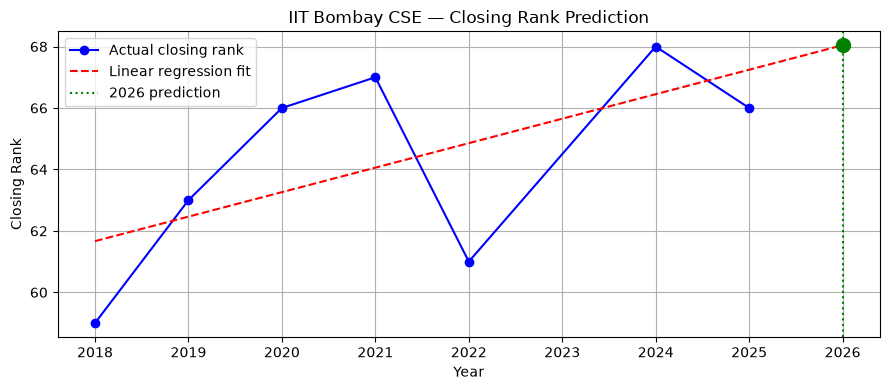

In [7]:
years_plot = np.linspace(X.min(), 2026, 100).reshape(-1, 1)
years_plot_norm = (years_plot - X.mean()) / X.std()
preds_plot = model.predict(years_plot_norm)

plt.figure(figsize=(9, 4))
plt.plot(seat['Year'], y, 'o-', color='blue', label='Actual closing rank')
plt.plot(years_plot, preds_plot, '--', color='red', label='Linear regression fit')
plt.axvline(x=2026, color='green', linestyle=':', label='2026 prediction')
plt.scatter([2026], [predicted], color='green', zorder=5, s=100)
plt.title("IIT Bombay CSE — Closing Rank Prediction")
plt.xlabel("Year")
plt.ylabel("Closing Rank")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()